# Raster-based collision loss for star domains

This notebook implements a **raster-based** alternative to the analytical `_multi_term_star_exclusion`.
Instead of sampling boundary/interior points and checking containment analytically, we:

1. Create a fixed pixel grid covering the scene.
2. **Soft-rasterize** each star domain: assign each pixel a value in [0, 1] indicating
   membership (using a sigmoid of `r_interp - dist`, so the function is smooth and
   differentiable w.r.t. centers and radii).
3. Compute the **overlap area** between pairs of domains as the sum of pixel-wise
   products of their soft masks.

The result is a scalar loss that is zero when the domains are disjoint and grows with
the overlapping area — with well-defined gradients everywhere.

Possible future improvements:

* Periodic B-splines

* log-radial parameterization

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", False)

## Soft rasterization of a star domain

A star domain is defined by a center `(cx, cy)` and `K` radii `r[k]` at angles
`θ_k = 2πk/K`.  A point `p` is inside the domain when its distance from the center
is less than the linearly-interpolated boundary radius at the angle of `p`.

We make this **soft** with a sigmoid:

$$m(p) = \sigma\!\left(\frac{r_{\text{interp}}(\angle p) - \|p - c\|}{T}\right)$$

where $T$ is a temperature parameter.  Small $T$ → hard boundary; larger $T$ →
blurred boundary with wider gradient support.

In [2]:
from vizopt.templates.raster_stars import make_pixel_grid, soft_rasterize_star, raster_collision_loss, optimize_star_domains_raster

## Pairwise overlap loss

The overlap area between domains $s$ and $t$ is approximated as:

$$\text{overlap}(s, t) = \text{pixel\_area} \cdot \sum_{p} m_s(p) \cdot m_t(p)$$

The collision loss sums the squared overlap over all masked pairs:

## Sanity check: visualise soft masks and overlap

Two star domains — one circle-like, one more irregular — placed with varying overlap.

Grid: (167, 200, 2), pixel_area=0.0009


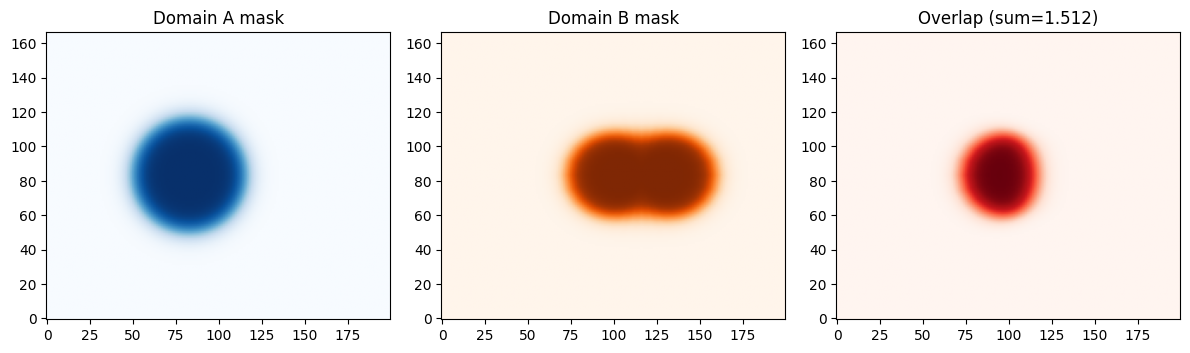

In [3]:
K = 32
angles = np.linspace(0, 2 * np.pi, K, endpoint=False).astype(np.float32)

# Domain A: near-circle of radius 1 centred at (-0.5, 0)
center_a = np.array([-0.5, 0.0], dtype=np.float32)
radii_a = np.ones(K, dtype=np.float32) * 1.0

# Domain B: slightly elliptical, centred at (0.5, 0)
center_b = np.array([0.5, 0.0], dtype=np.float32)
radii_b = (1.0 + 0.3 * np.cos(2 * angles)).astype(np.float32)

centers = np.stack([center_a, center_b])  # (2, 2)
radii = np.stack([radii_a, radii_b])      # (2, K)

grid_xy, pixel_area = make_pixel_grid(-3, 3, -2.5, 2.5, resolution=200)
print(f"Grid: {grid_xy.shape}, pixel_area={pixel_area:.4f}")

masks = soft_rasterize_star(
    jnp.array(centers),
    jnp.array(radii),
    jnp.array(grid_xy),
    temperature=0.1,
)
masks_np = np.array(masks)  # (2, H, W)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(masks_np[0], origin="lower", cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Domain A mask")
axes[1].imshow(masks_np[1], origin="lower", cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Domain B mask")
overlap_img = masks_np[0] * masks_np[1]
axes[2].imshow(overlap_img, origin="lower", cmap="Reds", vmin=0, vmax=1)
axes[2].set_title(f"Overlap (sum={overlap_img.sum() * pixel_area:.3f})")
plt.tight_layout()
plt.show()

## Loss and gradient as a function of centre separation

We sweep the x-offset between the two centres to verify:
- The loss is large when domains overlap heavily.
- The loss falls to ~0 when they are well separated.
- The gradient is smooth throughout.

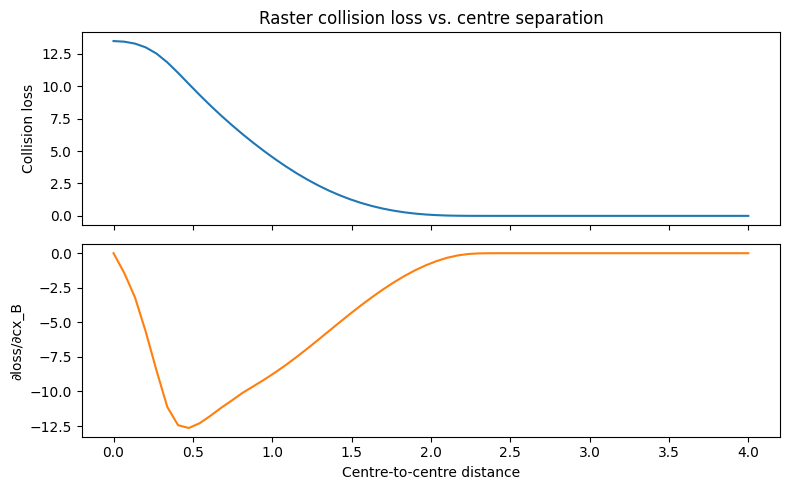

In [4]:
exclusion_mask = np.array([[False, True], [True, False]], dtype=bool)

input_params = {
    "grid_xy": jnp.array(grid_xy),
    "pixel_area": float(pixel_area),
    "exclusion_mask": jnp.array(exclusion_mask),
    "temperature": 0.04,
}

loss_jit = jax.jit(raster_collision_loss)
grad_fn = jax.jit(jax.grad(lambda ov, ip: raster_collision_loss(ov, ip)))

offsets = np.linspace(0.0, 4.0, 60)
losses, grads_cx = [], []

for dx in offsets:
    c = jnp.array([[-dx / 2, 0.0], [dx / 2, 0.0]], dtype=jnp.float32)
    ov = {"centers": c, "radii": jnp.array(radii)}
    losses.append(float(loss_jit(ov, input_params)))
    g = grad_fn(ov, input_params)
    # gradient of loss w.r.t. center_b x-component
    grads_cx.append(float(g["centers"][1, 0]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax1.plot(offsets, losses)
ax1.set_ylabel("Collision loss")
ax1.set_title("Raster collision loss vs. centre separation")
ax2.plot(offsets, grads_cx, color="tab:orange")
ax2.set_ylabel("∂loss/∂cx_B")
ax2.set_xlabel("Centre-to-centre distance")
plt.tight_layout()
plt.show()

## Temperature sensitivity

Lower temperature → sharper boundary → steeper loss; higher temperature → smoother gradient but
non-zero loss even for non-overlapping domains ("bleed" from the soft boundary).

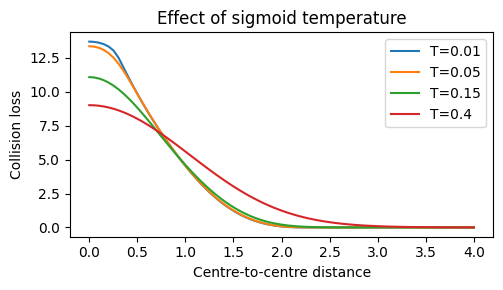

In [5]:
temperatures = [0.01, 0.05, 0.15, 0.40]
offsets_plot = np.linspace(0.0, 4.0, 80)

fig, ax = plt.subplots(figsize=(5, 3))
for T in temperatures:
    ip = {**input_params, "temperature": T}
    ls = []
    for dx in offsets_plot:
        c = jnp.array([[-dx / 2, 0.0], [dx / 2, 0.0]], dtype=jnp.float32)
        ov = {"centers": c, "radii": jnp.array(radii)}
        ls.append(float(loss_jit(ov, ip)))
    ax.plot(offsets_plot, ls, label=f"T={T}")

ax.set_xlabel("Centre-to-centre distance")
ax.set_ylabel("Collision loss")
ax.set_title("Effect of sigmoid temperature")
ax.legend()
plt.tight_layout()
plt.show()

## Wrapping as an `ObjectiveTerm`

The function already matches the `(optim_vars, input_params) → scalar` signature required
by `ObjectiveTerm`, so it can be dropped into any `OptimizationProblemTemplate` directly:

In [6]:
from vizopt.base import ObjectiveTerm, OptimConfig
from vizopt.templates.star_vs_star import _radius_from_target_area

raster_collision_term = ObjectiveTerm(
    name="raster_collision",
    compute=raster_collision_loss,
    multiplier=5.0,
)
print(raster_collision_term)

ObjectiveTerm(name='raster_collision', compute=<function raster_collision_loss at 0x000001720E6C2B60>, multiplier=5.0, schedule=None)


## Simple gradient descent demo

Push two initially-overlapping circular star domains apart using only the raster collision loss.

iter    0  loss=7.6445
iter   50  loss=0.0000
iter  100  loss=0.0000
iter  150  loss=0.0000
iter  200  loss=0.0000
iter  250  loss=0.0000
iter  300  loss=0.0000
iter  350  loss=0.0000


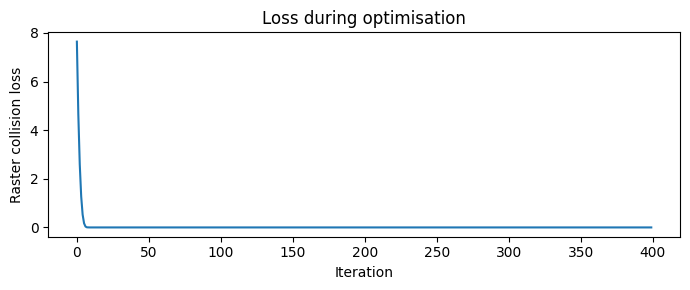

In [7]:
import optax

K = 48
angles_demo = np.linspace(0, 2 * np.pi, K, endpoint=False).astype(np.float32)

init_centers = jnp.array([[-0.3, 0.0], [0.3, 0.0]], dtype=jnp.float32)
init_radii = jnp.ones((2, K), dtype=jnp.float32) * 1.0

grid_demo, pa_demo = make_pixel_grid(-4, 4, -3, 3, resolution=128)
ip_demo = {
    "grid_xy": jnp.array(grid_demo),
    "pixel_area": float(pa_demo),
    "exclusion_mask": jnp.array([[False, True], [True, False]]),
    "temperature": 0.06,
}

optim = optax.adam(0.05)
ov = {"centers": init_centers, "radii": init_radii}
opt_state = optim.init(ov)

@jax.jit
def step(ov, opt_state):
    loss, grads = jax.value_and_grad(raster_collision_loss)(ov, ip_demo)
    updates, opt_state = optim.update(grads, opt_state)
    ov = optax.apply_updates(ov, updates)
    # Keep radii positive
    ov = {**ov, "radii": jnp.maximum(ov["radii"], 0.05)}
    return ov, opt_state, loss

history = []
for i in range(400):
    ov, opt_state, loss = step(ov, opt_state)
    if i % 50 == 0:
        print(f"iter {i:4d}  loss={float(loss):.4f}")
    history.append(float(loss))

plt.figure(figsize=(7, 3))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Raster collision loss")
plt.title("Loss during optimisation")
plt.tight_layout()
plt.show()

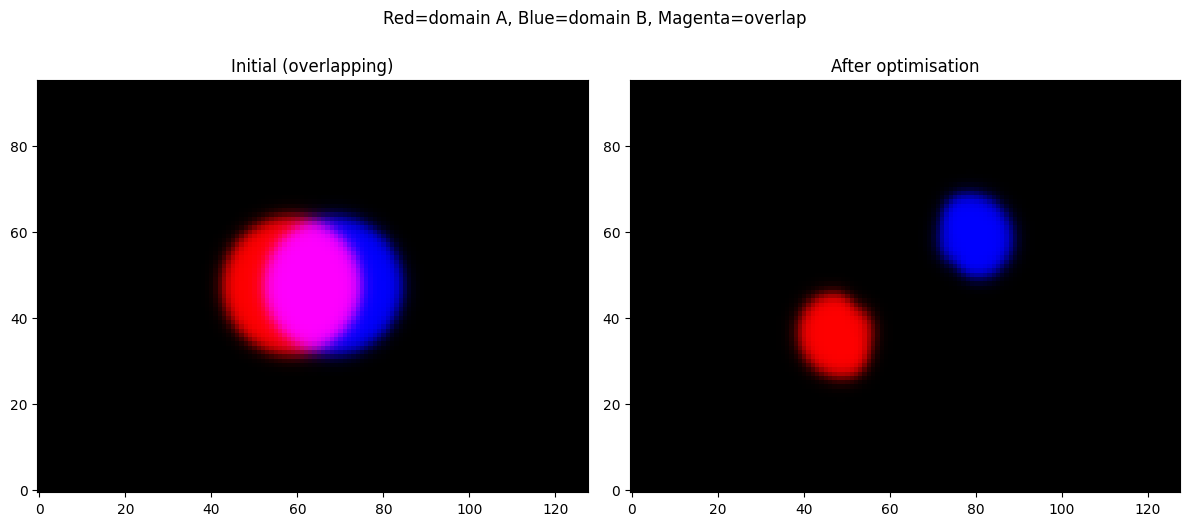

Final centres: A=[-0.8880511 -0.6543752], B=[0.88805217 0.6561257 ]
Separation: 2.207


In [8]:
# Visualise final configuration
final_masks = soft_rasterize_star(
    ov["centers"], ov["radii"], jnp.array(grid_demo), temperature=0.06
)
final_masks_np = np.array(final_masks)
init_masks = soft_rasterize_star(
    init_centers, init_radii, jnp.array(grid_demo), temperature=0.06
)
init_masks_np = np.array(init_masks)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, masks_np, title in [
    (axes[0], init_masks_np, "Initial (overlapping)"),
    (axes[1], final_masks_np, "After optimisation"),
]:
    rgb = np.zeros((*masks_np.shape[1:], 3))
    rgb[:, :, 0] = masks_np[0]  # domain 0 → red channel
    rgb[:, :, 2] = masks_np[1]  # domain 1 → blue channel
    # overlap → both channels lit → magenta
    ax.imshow(np.clip(rgb, 0, 1), origin="lower")
    ax.set_title(title)

plt.suptitle("Red=domain A, Blue=domain B, Magenta=overlap", y=1.02)
plt.tight_layout()
plt.show()

print(f"Final centres: A={np.array(ov['centers'][0])}, B={np.array(ov['centers'][1])}")
print(f"Separation: {float(jnp.linalg.norm(ov['centers'][0] - ov['centers'][1])):.3f}")

## `optimize_star_domains_raster`

A drop-in replacement for `star_vs_star.optimize_star_domains` that swaps the analytical
`_multi_term_star_exclusion` for the raster-based `raster_collision_loss`.

The **enclosure** constraint (inner set must stay inside outer set) remains analytical
(`_multi_term_star_enclosure`) because it is already well-behaved and does not suffer
from the "gap between sample points" issue that motivated the raster approach for exclusion.

The pixel grid is built once from the initial configuration and held fixed throughout
optimisation (it is part of `input_params`, not `optim_vars`).

## Demo: three domains with enclosure

- **Domain 0** (blue): target area 2, free to move.
- **Domain 1** (orange): target area 3, free to move.
- **Domain 2** (green, outer): no area target — shrinks to fit its contents.

Constraints:
- Domain 0 ⊂ Domain 2
- Domain 1 ⊂ Domain 2
- Domain 0 and Domain 1 must not overlap (raster collision loss).

In [11]:
representation = "b-spline"

In [12]:
from vizopt.animation import SnapshotCallback, snapshots_to_animated_svg
from IPython.display import SVG

K3 = 64
r0_init = _radius_from_target_area(2.0, K3)
r1_init = _radius_from_target_area(3.0, K3)
r_outer = max(r0_init, r1_init) * 2.5

# Place domains 0 and 1 overlapping slightly; domain 2 starts large and centred.
initial_centers_3 = np.array([
    [-r0_init * 0.4,  0.0],   # 0: left inner
    [ r1_init * 0.4,  0.0],   # 1: right inner (overlaps 0 at start)
    [          0.0,   0.0],   # 2: outer container
], dtype=np.float32)

cb3 = SnapshotCallback(every=20)

results3, history3, problem3 = optimize_star_domains_raster(
    n_sets=3,
    initial_centers=initial_centers_3,
    representation=representation,
    #k_angles=K3,
    target_areas=[2.0, 3.0, None],
    initial_radius=r_outer,
    weight_target_area=15.0,
    weight_area=0.5,
    weight_perimeter=0.3,
    weight_exclusion=8.0,
    weight_enclosure=25.0,
    weight_smoothness=0.5,
    enclosures=[(0, 2), (1, 2)],
    enclosure_offset=0.2,
    exclusion_offset=0.1,
    grid_resolution=96,
    temperature=0.08,
    optim_config=OptimConfig(n_iters=1500, learning_rate=4e-3),
    callback=cb3,
)

Pixel grid: 86x96, pixel_area=0.0047
Iteration 0: loss = 64.57182312011719
Iteration 100: loss = 16.682659149169922
Iteration 200: loss = 14.187138557434082
Iteration 300: loss = 13.132883071899414
Iteration 400: loss = 12.821734428405762
Iteration 500: loss = 12.732555389404297
Iteration 600: loss = 12.697169303894043
Iteration 700: loss = 12.68120288848877
Iteration 800: loss = 12.675390243530273
Iteration 900: loss = 12.672771453857422
Iteration 1000: loss = 12.671650886535645
Iteration 1100: loss = 12.670458793640137
Iteration 1200: loss = 12.669053077697754
Iteration 1300: loss = 12.66845703125
Iteration 1400: loss = 12.668158531188965


In [13]:
K3 = results3[0]["angles"].shape[0]
dt3 = 2 * np.pi / K3
for s, res in enumerate(results3):
    r = res["radii"]
    area = 0.5 * np.sin(dt3) * np.sum(r * np.roll(r, -1))
    target = [2.0, 3.0, "—"][s]
    print(f"Domain {s}: area = {area:.3f}  (target: {target})")

Domain 0: area = 1.939  (target: 2.0)
Domain 1: area = 2.944  (target: 3.0)
Domain 2: area = 6.979  (target: —)


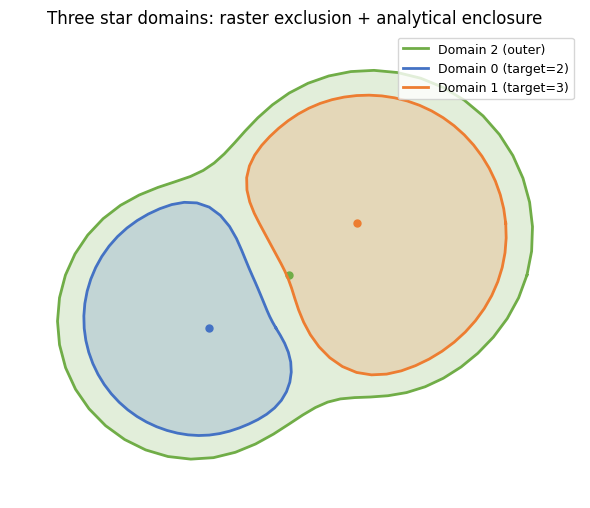

In [14]:
COLORS = ["#4472c4", "#ed7d31", "#70ad47"]
LABELS = ["Domain 0 (target=2)", "Domain 1 (target=3)", "Domain 2 (outer)"]

fig, ax = plt.subplots(figsize=(6, 6))
# Draw outer first so inner domains render on top
for s in [2, 0, 1]:
    res = results3[s]
    cx, cy = res["center"]
    r = res["radii"]
    angs = res["angles"]
    bx = np.append(cx + r * np.cos(angs), cx + r[0] * np.cos(angs[0]))
    by = np.append(cy + r * np.sin(angs), cy + r[0] * np.sin(angs[0]))
    ax.fill(bx, by, color=COLORS[s], alpha=0.20)
    ax.plot(bx, by, color=COLORS[s], lw=2, label=LABELS[s])
    ax.plot(cx, cy, "o", color=COLORS[s], ms=5)

ax.set_aspect("equal")
ax.autoscale_view()
ax.margins(0.1)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Three star domains: raster exclusion + analytical enclosure")
ax.axis("off")
plt.tight_layout()
plt.show()

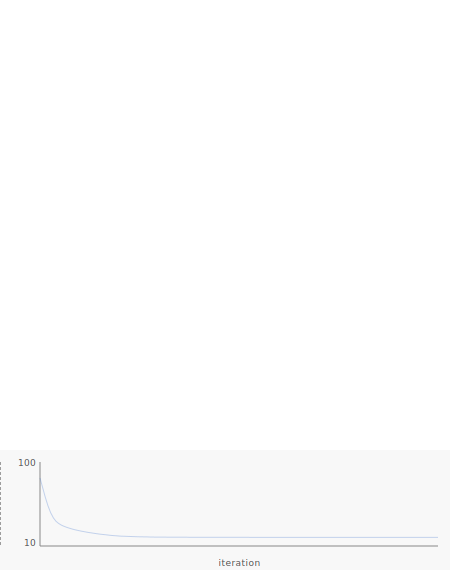

In [15]:
svg3 = snapshots_to_animated_svg(
    problem3, cb3.snapshots, fps=10, size=450, history=history3, log_scale=True
)
SVG(data=svg3)

## British Isles examples

In [16]:
include_ireland_island = True

if include_ireland_island:
    set_names = [
        "England",              # 0
        "Scotland",             # 1
        "Wales",                # 2
        "Great Britain",        # 3: England + Scotland + Wales
        "Northern Ireland",     # 4
        "Republic of Ireland",  # 5
        "Crown Dependencies",   # 6: Isle of Man, Jersey, Guernsey
        "United Kingdom",       # 7: Great Britain + Northern Ireland
        "Ireland island",       # 8: Northern Ireland + Republic of Ireland
        "British Islands",      # 9: UK + Ireland island + Crown Dependencies
    ]
    enclosures = [
        (0, 3),   # England ⊂ Great Britain
        (1, 3),   # Scotland ⊂ Great Britain
        (2, 3),   # Wales ⊂ Great Britain
        (3, 7),   # Great Britain ⊂ United Kingdom
        (4, 7),   # Northern Ireland ⊂ United Kingdom
        (4, 8),   # Northern Ireland ⊂ Ireland island
        (5, 8),   # Republic of Ireland ⊂ Ireland island
        (7, 9),   # United Kingdom ⊂ British Islands
        (8, 9),   # Ireland island ⊂ British Islands
        (6, 9),   # Crown Dependencies ⊂ British Islands
    ]
    target_areas = [
        3.40,  # 0: England
        2.00,  # 1: Scotland
        0.55,  # 2: Wales
        None,  # 3: Great Britain
        0.40,  # 4: Northern Ireland
        1.80,  # 5: Republic of Ireland
        0.15,  # 6: Crown Dependencies
        None,  # 7: United Kingdom
        None,  # 8: Ireland island
        None,  # 9: British Islands
    ]
    initial_centers = np.array([
        [ 3.2,  0.5],   # 0: England
        [ 1.8,  3.5],   # 1: Scotland
        [ 1.5, -0.5],   # 2: Wales
        [ 2.5,  1.5],   # 3: Great Britain
        [-1.5,  4.5],   # 4: Northern Ireland
        [-2.5,  0.5],   # 5: Republic of Ireland
        [ 5.0, -1.5],   # 6: Crown Dependencies
        [ 0.5,  3.0],   # 7: United Kingdom
        [-2.0,  2.5],   # 8: Ireland island
        [ 0.5,  1.5],   # 9: British Islands
    ], dtype=np.float32)
else:
    set_names = [
        "England",              # 0
        "Scotland",             # 1
        "Wales",                # 2
        "Great Britain",        # 3: England + Scotland + Wales
        "Northern Ireland",     # 4
        "Republic of Ireland",  # 5
        "Crown Dependencies",   # 6: Isle of Man, Jersey, Guernsey
        "United Kingdom",       # 7: Great Britain + Northern Ireland
        "British Islands",      # 8: UK + Republic of Ireland + Crown Dependencies
    ]
    enclosures = [
        (0, 3),   # England ⊂ Great Britain
        (1, 3),   # Scotland ⊂ Great Britain
        (2, 3),   # Wales ⊂ Great Britain
        (3, 7),   # Great Britain ⊂ United Kingdom
        (4, 7),   # Northern Ireland ⊂ United Kingdom
        (7, 8),   # United Kingdom ⊂ British Islands
        (5, 8),   # Republic of Ireland ⊂ British Islands
        (6, 8),   # Crown Dependencies ⊂ British Islands
    ]
    target_areas = [
        3.40,  # 0: England
        2.00,  # 1: Scotland
        0.55,  # 2: Wales
        None,  # 3: Great Britain
        0.40,  # 4: Northern Ireland
        1.80,  # 5: Republic of Ireland
        0.15,  # 6: Crown Dependencies
        None,  # 7: United Kingdom
        None,  # 8: British Islands
    ]
    initial_centers = np.array([
        [ 3.2,  0.5],   # 0: England
        [ 1.8,  3.5],   # 1: Scotland
        [ 1.5, -0.5],   # 2: Wales
        [ 2.5,  1.5],   # 3: Great Britain
        [-1.5,  4.5],   # 4: Northern Ireland
        [-2.5,  0.5],   # 5: Republic of Ireland
        [ 5.0, -1.5],   # 6: Crown Dependencies
        [ 0.5,  3.0],   # 7: United Kingdom
        [ 1.0,  1.5],   # 8: British Islands
    ], dtype=np.float32)

S = len(set_names)

cb_bi = SnapshotCallback(every=100)

results_bi, history_bi, problem_bi = optimize_star_domains_raster(
    n_sets=S,
    initial_centers=initial_centers,
    representation=representation,
    #k_angles=128,
    target_areas=target_areas,
    initial_radius=5.0,
    weight_target_area=20.0,
    weight_area=0.3,
    weight_perimeter=0.3,
    weight_exclusion=15.0,
    weight_enclosure=30.0,
    weight_smoothness=2.0,
    enclosures=enclosures,
    grid_resolution=128,
    enclosure_offset=0.2,
    exclusion_offset=0.1,
    temperature=0.1,
    optim_config=OptimConfig(n_iters=12000, learning_rate=0.01),
    callback=cb_bi,
)
print(f"Captured {len(cb_bi.snapshots)} snapshots")


Pixel grid: 118x128, pixel_area=0.0208
Iteration 0: loss = 52169.2578125
Iteration 100: loss = 4783.55029296875
Iteration 200: loss = 974.6326293945312
Iteration 300: loss = 319.4929504394531
Iteration 400: loss = 185.69334411621094
Iteration 500: loss = 155.11126708984375
Iteration 600: loss = 146.24232482910156
Iteration 700: loss = 142.72940063476562
Iteration 800: loss = 140.8395538330078
Iteration 900: loss = 139.53811645507812
Iteration 1000: loss = 138.49388122558594
Iteration 1100: loss = 137.57284545898438
Iteration 1200: loss = 136.7135467529297
Iteration 1300: loss = 135.8866424560547
Iteration 1400: loss = 135.07313537597656
Iteration 1500: loss = 134.2655029296875
Iteration 1600: loss = 133.4530029296875
Iteration 1700: loss = 132.635009765625
Iteration 1800: loss = 131.8143768310547
Iteration 1900: loss = 130.99671936035156
Iteration 2000: loss = 130.16552734375
Iteration 2100: loss = 129.31605529785156
Iteration 2200: loss = 128.44515991210938
Iteration 2300: loss = 127.

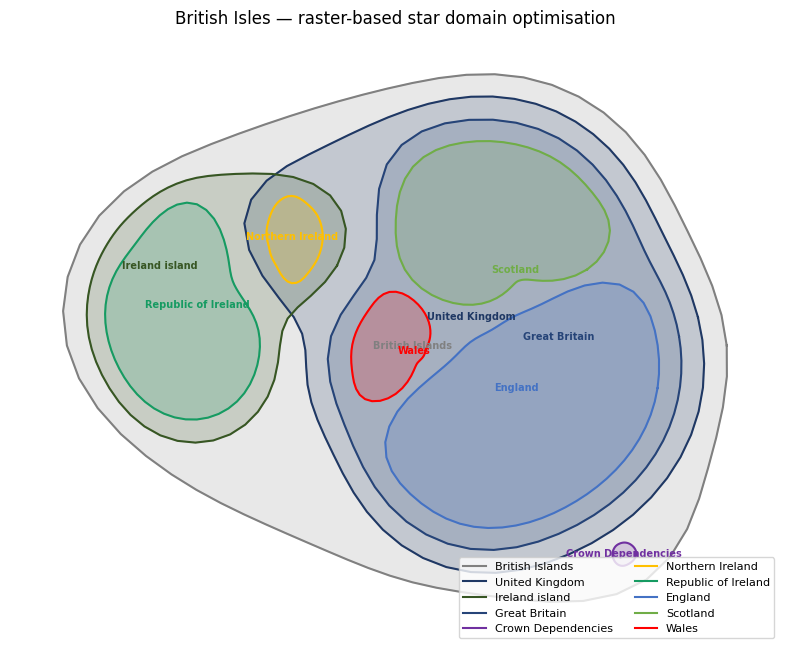

In [17]:
COLORS_BI = {
    0: "#4472c4",   # England
    1: "#70ad47",   # Scotland
    2: "#ff0000",   # Wales
    3: "#264478",   # Great Britain
    4: "#ffc000",   # Northern Ireland
    5: "#169b62",   # Republic of Ireland
    6: "#7030a0",   # Crown Dependencies
    7: "#1f3864",   # United Kingdom
    8: "#375623",   # Ireland island
    9: "#808080",   # British Islands
}

# Draw outermost sets first so inner sets render on top
draw_order = [9, 7, 8, 3, 6, 4, 5, 0, 1, 2]

fig, ax = plt.subplots(figsize=(8, 8))
for s in draw_order:
    res = results_bi[s]
    cx, cy = res["center"]
    r = res["radii"]
    angs = res["angles"]
    bx = np.append(cx + r * np.cos(angs), cx + r[0] * np.cos(angs[0]))
    by = np.append(cy + r * np.sin(angs), cy + r[0] * np.sin(angs[0]))
    color = COLORS_BI[s]
    ax.fill(bx, by, color=color, alpha=0.18)
    ax.plot(bx, by, color=color, lw=1.5, label=set_names[s])
    ax.text(cx, cy, set_names[s], ha="center", va="center", fontsize=7, color=color, fontweight="bold")

ax.set_aspect("equal")
ax.autoscale_view()
ax.margins(0.08)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.set_title("British Isles — raster-based star domain optimisation")
ax.axis("off")
plt.tight_layout()
plt.show()

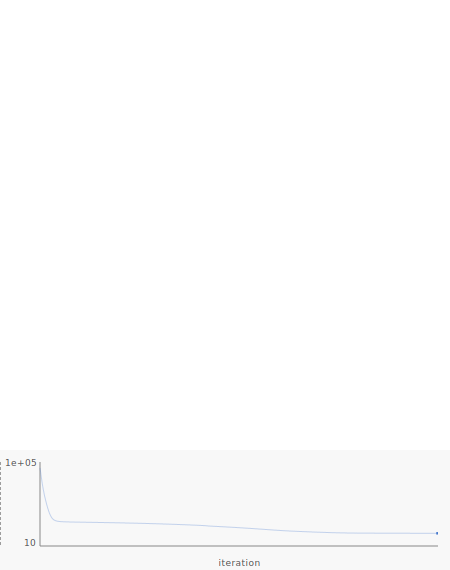

In [18]:
svg_bi = snapshots_to_animated_svg(
    problem_bi, cb_bi.snapshots, fps=10, size=450, history=history_bi, log_scale=True
)
SVG(data=svg_bi)